## Preprocessing for new data for transformer method


In [ ]:
# Import libraries

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
! pip install langdetect
from langdetect import detect, DetectorFactory

In [2]:
# Load data
csv_paths = list(Path("../Dataset/data_new_approach/").glob("*.csv"))
raw = pd.concat(
    [
        pd.read_csv(p, dtype=str).assign(source_file=p.name)
        for p in csv_paths
    ],
    ignore_index=True
)

print(f"Shape: {raw.shape}")
raw.head()
# Basic check
print(raw.info())
print("\nMissing values:")
print(raw.isnull().sum())

print("\nPlatform distribution:")
print(raw['platform'].value_counts())

print("\nRating distribution:")
print(raw['rating'].value_counts().sort_index())

Shape: (5450, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5450 entries, 0 to 5449
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   platform       5450 non-null   object
 1   storefront     5450 non-null   object
 2   app_id         2450 non-null   object
 3   review_id      5450 non-null   object
 4   date           5450 non-null   object
 5   user           5450 non-null   object
 6   rating         5450 non-null   object
 7   title          2450 non-null   object
 8   review         5450 non-null   object
 9   version        2450 non-null   object
 10  package        3000 non-null   object
 11  thumbsUpCount  3000 non-null   object
 12  appVersion     2774 non-null   object
 13  source_file    5450 non-null   object
dtypes: object(14)
memory usage: 596.2+ KB
None

Missing values:
platform            0
storefront          0
app_id           3000
review_id           0
date                0
user        

In [ ]:
missing_raw = (
    raw.isna().sum()
    .reset_index()
)
missing_raw.columns = ['variable', 'n_missing']
missing_raw = missing_raw.sort_values('n_missing', ascending=False).reset_index(drop=True)
print(missing_raw)

In [3]:
# Select relevant columns & basic cleaning
df = raw[['platform', 'storefront', 'rating', 'title', 'review', 'date', 'source_file']].copy()

# Fix dtypes
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['title'] = df['title'].fillna('')
df['text'] = df.apply(
    lambda row: (row['title'] + ' ' + row['review']).strip() if row['title'] else row['review'],
    axis=1
)

print(df.shape)
print(df[['platform', 'title', 'review', 'text']].head(5))

(5450, 8)
    platform          title  \
0  app_store  No ATM option   
1  app_store    Great Bank.   
2  app_store           Pato   
3  app_store   Saving or CD   
4  app_store     Easy peasy   

                                              review  \
0                                    No debit card 😣   
1  Really easy bank to use. The best interest rat...   
2                                              Great   
3  Easy to navigate and transfers back to account...   
4  Very easy to use and efficient!  Good interest...   

                                                text  
0                      No ATM option No debit card 😣  
1  Great Bank. Really easy bank to use. The best ...  
2                                         Pato Great  
3  Saving or CD Easy to navigate and transfers ba...  
4  Easy peasy Very easy to use and efficient!  Go...  


In [4]:
# Create sentiment label from rating
def rating_to_sentiment(r):
    if r <= 2:
        return 'negative'
    elif r == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['rating'].apply(rating_to_sentiment)
df['label'] = df['sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})

print(df['sentiment'].value_counts())
print(df['label'].value_counts())

sentiment
positive    3575
negative    1641
neutral      234
Name: count, dtype: int64
label
2    3575
0    1641
1     234
Name: count, dtype: int64


In [ ]:
DetectorFactory.seed = 0

def detect_language(text):
    text = str(text).strip()
    if not text:
        return "unknown"
    try:
        return detect(text)
    except:
        return "unknown"

df['language'] = df['text'].apply(detect_language)

print(df['language'].value_counts())

df = df[df['language'] == 'en'].copy().reset_index(drop=True)
print(f"After language filter: {df.shape}") 

language
en    4478
Name: count, dtype: int64
After language filter: (4478, 13)


In [5]:
# Text cleaning
# for bert model i remove URLs, punctuation, extra spaces and lowercases

def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text)
    text = text.lower()                      
    text = re.sub(r'http\S+|www\S+', '', text)      
    text = re.sub(r'\s+', ' ', text).strip()   
    return text

df['text_clean'] = df['text'].apply(clean_text)

print(df[['review', 'text_clean']].head(3))
df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)
print(f"\nFinal shape: {df.shape}")

                                              review  \
0                                    No debit card 😣   
1  Really easy bank to use. The best interest rat...   
2                                              Great   

                                          text_clean  
0                      no atm option no debit card 😣  
1  great bank. really easy bank to use. the best ...  
2                                         pato great  

Final shape: (5450, 11)


count    5450.000000
mean       22.044587
std        29.047547
min         1.000000
25%         4.000000
50%        11.000000
75%        28.000000
max       377.000000
Name: text_length, dtype: float64

Reviews > 512 words: 0
Reviews > 256 words: 7
Reviews > 128 words: 62


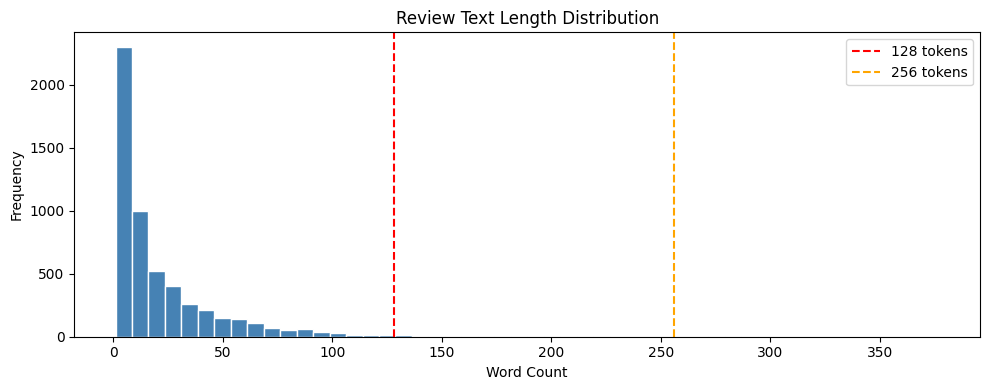

In [6]:
# Check text length
df['text_length'] = df['text_clean'].apply(lambda x: len(x.split()))

print(df['text_length'].describe())
print(f"\nReviews > 512 words: {(df['text_length'] > 512).sum()}")
print(f"Reviews > 256 words: {(df['text_length'] > 256).sum()}")
print(f"Reviews > 128 words: {(df['text_length'] > 128).sum()}")

# Visualize
plt.figure(figsize=(10, 4))
plt.hist(df['text_length'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(128, color='red', linestyle='--', label='128 tokens')
plt.axvline(256, color='orange', linestyle='--', label='256 tokens')
plt.title('Review Text Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150)
plt.show()
# max length not over 512, available for bert model

In [ ]:
# prepare for train and test split(havnt run)

train, temp = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val, test = train_test_split(temp, test_size=0.5, random_state=42, stratify=temp['label'])

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")